In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, Average, Layer, Concatenate, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from skimage import color
import matplotlib.pyplot as plt
import os
from google.colab import files

In [2]:
print("Por favor, sube tu archivo kaggle.json")
files.upload() # Aparecerá un botón para subir el archivo

# Configuramos los permisos y el directorio de Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Descargamosusando el link del dataset
print("Descargando el dataset de caricaturas...")
!kaggle datasets download -d volkandl/cartoon-classification

# Descomprimimos en la carpeta 'dataset'
print("Descomprimiendo...")
!unzip -q cartoon-classification.zip -d dataset/
print("Dataset listo")

Por favor, sube tu archivo kaggle.json


Saving kaggle.json to kaggle.json
Descargando el dataset de caricaturas...
Dataset URL: https://www.kaggle.com/datasets/volkandl/cartoon-classification
License(s): CC0-1.0
100% 11.5G/11.5G [02:12<00:00, 93.0MB/s]

Descomprimiendo...
Dataset listo


In [4]:
class CapaRBFEspacial(Layer):

    """Capa matemática RBF"""
    def __init__(self, num_centros, gamma=1.0, **kwargs):
        super(CapaRBFEspacial, self).__init__(**kwargs)
        self.num_centros = num_centros
        self.gamma = gamma

    def build(self, input_shape):
        canales = input_shape[-1]
        self.mu = self.add_weight(name='centros_rbf',
                                  shape=(1, 1, 1, canales, self.num_centros),
                                  initializer='random_normal',
                                  trainable=True)
        super(CapaRBFEspacial, self).build(input_shape)

    def call(self, inputs):
        inputs_exp = tf.expand_dims(inputs, axis=-1)
        diferencia = inputs_exp - self.mu
        distancia_l2_cuadrada = tf.reduce_sum(tf.square(diferencia), axis=-2)
        return tf.exp(-self.gamma * distancia_l2_cuadrada)


def metrica_psnr(y_true, y_pred):
    # max_val es 2.0 porque nuestra red usa 'tanh' y los valores van de -1 a 1 (rango total = 2)
    return tf.image.psnr(y_true, y_pred, max_val=2.0)

def metrica_ssim(y_true, y_pred):
    # Compara la similitud estructural de los canales a y b
    return tf.image.ssim(y_true, y_pred, max_val=2.0)

def unet_hibrida(alto=128, ancho=128):
    entrada_L = Input(shape=(alto, ancho, 1), name="Entrada_Escala_Grises")

    # 1. ENCODER (Extracción guardando alta resolución)

    # Nivel 1: Alta resolución (128x128)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(entrada_L)
    p1 = Conv2D(64, (3, 3), activation='relu', padding='same', strides=2)(c1)

    # Nivel 2: Media resolución (64x64)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    p2 = Conv2D(128, (3, 3), activation='relu', padding='same', strides=2)(c2)

    # Cuello de botella: Baja resolución (32x32) - Aquí se entiende el "contexto" global
    cuello = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)

    # 2. DECODER CON SKIP CONNECTIONS (U-Net)

    # Subimos a 64x64 y CONCATENAMOS con 'c2' para recuperar bordes medios
    u1 = UpSampling2D((2, 2), interpolation='bilinear')(cuello)
    merge1 = Concatenate()([u1, c2])
    d1 = Conv2D(128, (3, 3), activation='relu', padding='same')(merge1)

    # Subimos a 128x128 y CONCATENAMOS con 'c1' para recuperar bordes finos
    u2 = UpSampling2D((2, 2), interpolation='bilinear')(d1)
    merge2 = Concatenate()([u2, c1])

    # Vector de características profundo final (con bordes nítidos)
    caracteristicas_unet = Conv2D(64, (3, 3), activation='relu', padding='same')(merge2)

    # 3. Toma de decisiones de color

    # Cabeza MLP Aproximación global
    cabeza_mlp = Conv2D(32, (1, 1), activation='relu')(caracteristicas_unet)
    salida_mlp = Conv2D(2, (1, 1), activation='tanh', name="Salida_MLP")(cabeza_mlp)

    # Cabeza RBF Aproximación por prototipos de color
    activacion_rbf = CapaRBFEspacial(num_centros=30, gamma=0.5)(caracteristicas_unet)
    salida_rbf = Conv2D(2, (1, 1), activation='tanh', name="Salida_RBF")(activacion_rbf)

    # 4. FUSIÓN APRENDIDA FINAL

    merged_heads = Concatenate(axis=-1)([salida_mlp, salida_rbf])
    salida_fusion = Conv2D(2, (1, 1), activation='tanh', name="Prediccion_Final_ab")(merged_heads)

    modelo = Model(inputs=entrada_L, outputs=salida_fusion, name="UNet_Hibrida")
    modelo.compile(optimizer='adam',
                   loss='mse',
                   metrics=[metrica_psnr, metrica_ssim])
    return modelo

# Instanciamos el nuevo modelo
modelo_color = unet_hibrida()

In [5]:
def generador_datos_lab(ruta_dataset, batch_size=16, target_size=(128, 128)):
    datagen = ImageDataGenerator(rescale=1./255)

    # class_mode=None porque las etiquetas de clasificación no nos sirven aquí
    generador = datagen.flow_from_directory(
        ruta_dataset,
        target_size=target_size,
        batch_size=batch_size,
        class_mode=None,
        shuffle=True
    )

    while True:
        try:
            lote_rgb = next(generador)
            # Aseguramos que se tengan las dimensiones correctas antes de convertir
            if lote_rgb.shape[0] == 0:
                continue

            lote_lab = color.rgb2lab(lote_rgb)

            x_batch = lote_lab[:, :, :, 0:1]
            x_batch = (x_batch / 50.0) - 1.0 # Normalizar L

            y_batch = lote_lab[:, :, :, 1:3]
            y_batch = y_batch / 128.0        # Normalizar a, b

            yield (x_batch, y_batch)
        except Exception as e:
            # En caso de alguna imagen corrupta en el dataset, la ignora y sigue
            continue

In [6]:
ruta_train = 'dataset/cartoon_classification/TRAIN'
ruta_test = 'dataset/cartoon_classification/TEST'

# Iniciamos los generadores
gen_entrenamiento = generador_datos_lab(ruta_train, batch_size=16)
gen_prueba = generador_datos_lab(ruta_test, batch_size=1)

print("Iniciando entrenamiento del ensamble CNN + MLP/RBF...")
# Usamos 600 pasos por época aunque tarde un poco para tener un mejor resultado
historia = modelo_color.fit(
    gen_entrenamiento,
    steps_per_epoch=600,
    epochs=25
)

Iniciando entrenamiento del ensamble CNN + MLP/RBF...
Found 119617 images belonging to 10 classes.
Epoch 1/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 114s 145ms/step - loss: 0.0426 - metrica_psnr: 21.4245 - metrica_ssim: 0.1700
Epoch 2/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 84s 140ms/step - loss: 0.0292 - metrica_psnr: 22.2585 - metrica_ssim: 0.2065
Epoch 3/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 83s 139ms/step - loss: 0.0285 - metrica_psnr: 22.3466 - metrica_ssim: 0.2236
Epoch 4/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 84s 139ms/step - loss: 0.0271 - metrica_psnr: 22.5211 - metrica_ssim: 0.2436
Epoch 5/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 83s 139ms/step - loss: 0.0265 - metrica_psnr: 22.5763 - metrica_ssim: 0.2561
Epoch 6/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 83s 138ms/step - loss: 0.0245 - metrica_psnr: 22.9446 - metrica_ssim: 0.2795
Epoch 7/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 84s 140ms/step - loss: 0.0225 - metrica_psnr: 23.3017 - metrica_ssim: 0.3104
Epoch 8/25
600/600 ━━━━━━━━━━━━━━━━━━━━ 84s 140ms/step - loss: 0.0206 - metrica_p

La red está coloreando la imagen...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


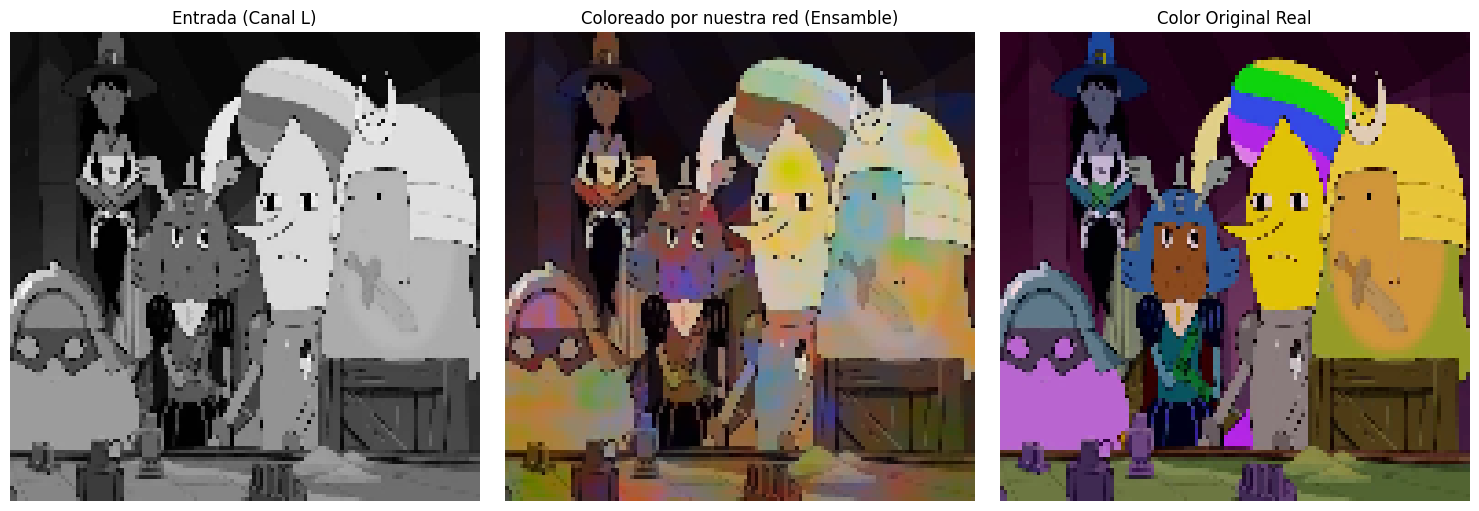

In [16]:
# Extraemos una imagen de prueba
L_real_norm, ab_real_norm = next(gen_prueba)

# Hacemos la predicción
print("La red está coloreando la imagen...")
ab_predicho_norm = modelo_color.predict(L_real_norm)

# Desnormalizamos todos los tensores
L = (L_real_norm[0] + 1.0) * 50.0
ab_predicho = ab_predicho_norm[0] * 128.0
ab_real = ab_real_norm[0] * 128.0

# Unimos los canales
imagen_predicha_lab = np.concatenate([L, ab_predicho], axis=-1)
imagen_real_lab = np.concatenate([L, ab_real], axis=-1)

# Convertimos a RGB
# Usamos np.clip para evitar advertencias si algún pixel se sale del límite al desnormalizar
imagen_predicha_rgb = np.clip(color.lab2rgb(imagen_predicha_lab), 0, 1)
imagen_real_rgb = np.clip(color.lab2rgb(imagen_real_lab), 0, 1)

# Graficamos los resultados comparativos
plt.figure(figsize=(15, 5))

# Imagen 1: Entrada
plt.subplot(1, 3, 1)
plt.imshow(L[:, :, 0], cmap='gray')
plt.title('Entrada (Canal L)')
plt.axis('off')

# Imagen 2: Predicción de la Red
plt.subplot(1, 3, 2)
plt.imshow(imagen_predicha_rgb)
plt.title('Coloreado por nuestra red (Ensamble)')
plt.axis('off')

# Imagen 3: Ground Truth
plt.subplot(1, 3, 3)
plt.imshow(imagen_real_rgb)
plt.title('Color Original Real')
plt.axis('off')

plt.tight_layout()
plt.show()